## Data Preprocessing

1. Data Loading and Initial Exploration

In [133]:
import pandas as pd

data = pd.read_csv("breast-cancer.csv")

print(data.head())
print(data.shape)
print(data.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

2. Check missing values

In [134]:
print(data.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


3. Remove useless columns

In [135]:
if 'id' in data.columns:
    data = data.drop('id', axis=1)

4. Detect outliers (Method IQR)

In [136]:


numeric_data = data.select_dtypes(include=['float64', 'int64'])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1


outliers = ((numeric_data < (Q1 - 1.5 * IQR)) | (numeric_data > (Q3 + 1.5 * IQR)))

print(outliers.sum())

radius_mean                14
texture_mean                7
perimeter_mean             13
area_mean                  25
smoothness_mean             6
compactness_mean           16
concavity_mean             18
concave points_mean        10
symmetry_mean              15
fractal_dimension_mean     15
radius_se                  38
texture_se                 20
perimeter_se               38
area_se                    65
smoothness_se              30
compactness_se             28
concavity_se               22
concave points_se          19
symmetry_se                27
fractal_dimension_se       28
radius_worst               17
texture_worst               5
perimeter_worst            15
area_worst                 35
smoothness_worst            7
compactness_worst          16
concavity_worst            12
concave points_worst        0
symmetry_worst             23
fractal_dimension_worst    24
dtype: int64


5. Handle target column

In [137]:
#M = Malignant => 1
#B = Benign => 0
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

6. Define features and target

In [138]:
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

7. Data Splitting into Training and Testing Sets (80/20)

In [139]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

8. Feature Scaling (value → (value - mean) / std)

In [140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

******

# K-Nearest Neighbors (KNN) Model Implementation

1. Model Initialization

In [141]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

2. Elbow Method (Choosing Best K)

Best K: 9
Best Accuracy: 0.9649


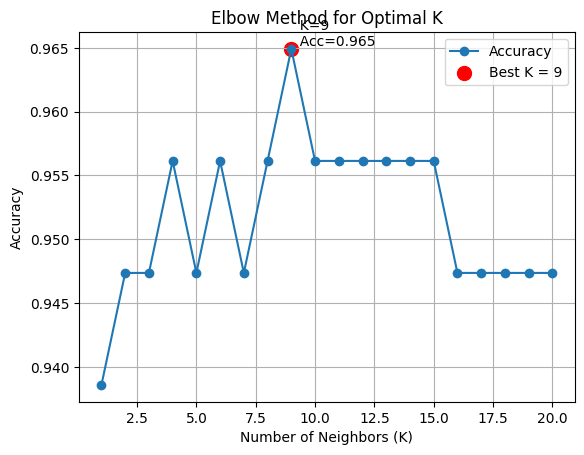

In [142]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

k_values = range(1, 21)
accuracies = []


for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))


best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)

print(f"Best K: {best_k}")
print(f"Best Accuracy: {best_acc:.4f}")

plt.figure()
plt.plot(k_values, accuracies, marker='o', label="Accuracy")


plt.scatter(best_k, best_acc, color='red', s=100, label=f"Best K = {best_k}")

plt.text(best_k, best_acc,
         f"  K={best_k}\n  Acc={best_acc:.3f}",
         verticalalignment='bottom')

# Labels
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Optimal K")
plt.legend()
plt.grid()

plt.show()

3. Train Final Model (with K=9)

In [143]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=9)

4. Prediction

In [144]:
y_pred = knn.predict(X_test)

5. Evaluation

In [145]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[69  2]
 [ 2 41]]


*****

# Logistic Regression Model

1. Model Initialization

In [146]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

2. Training the Model

In [147]:
lr.fit(X_train, y_train)

LogisticRegression()

3. Prediction

In [148]:
y_pred_lr = lr.predict(X_test)

4. Evaluation

In [149]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[70  1]
 [ 2 41]]


*****

# Random Forest Model

1. Model Initialization

In [150]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, min_samples_split=5, max_depth=10, random_state=42)

2. Training the Model

In [151]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=150,
                       random_state=42)

3. Prediction

In [152]:
y_pred_rf = rf.predict(X_test)

4. Evaluation

In [153]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9649122807017544

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
 [[70  1]
 [ 3 40]]


5. Feature Importance

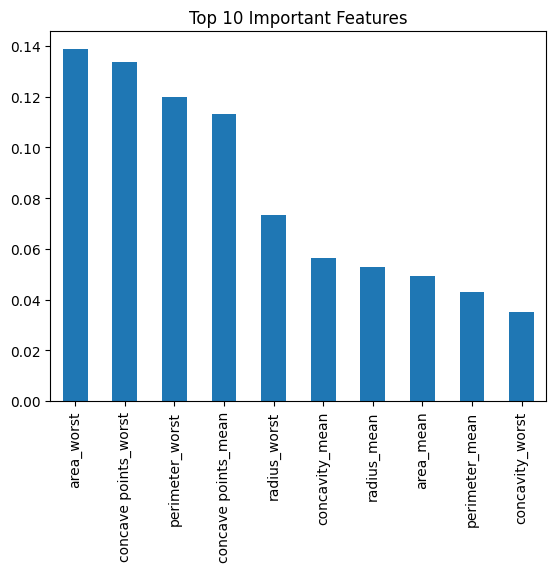

In [154]:

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

6. Hyperparameter Optimization using Randomized Search (Random Forest)

In [155]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)


param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)


random_search.fit(X_train, y_train)


best_rf = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Best parameters: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': 10}


****

# XGBoost Model

1. Import and Initialize

In [156]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

2. Train the Model

In [157]:
xgb.fit(X_train, y_train)

C:\Users\mouch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\xgboost\core.py:158: UserWarning: [03:53:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

3. Prediction

In [158]:
y_pred_xgb = xgb.predict(X_test)

4. Evaluation

In [159]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
 [[69  2]
 [ 3 40]]


5.Feature Importance

C:\Users\mouch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\xgboost\core.py:158: UserWarning: [03:53:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


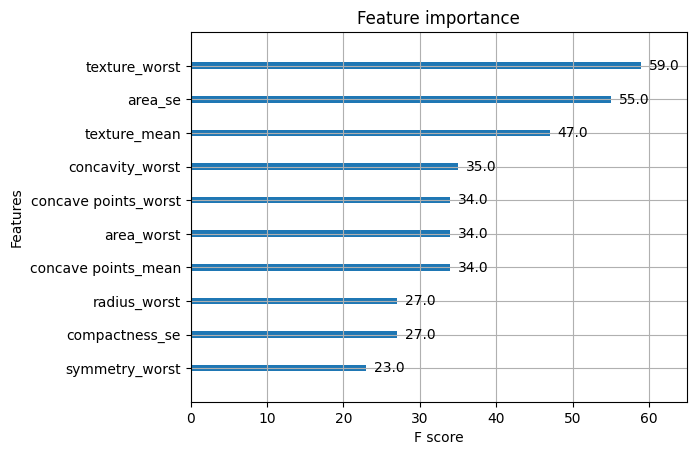

In [160]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

xgb.fit(X_train, y_train)

from xgboost import plot_importance
plot_importance(xgb, max_num_features=10)
plt.show()

 6. Hyperparameter Optimization using Randomized Search (XGBoost Model)

In [161]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.2]
}


random_search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

best_xgb = random_search_xgb.best_estimator_


y_pred_xgb = best_xgb.predict(X_test)


print("Best parameters found:", random_search_xgb.best_params_)

C:\Users\mouch\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\xgboost\core.py:158: UserWarning: [03:53:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters found: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1}


****

# Model Comparison

In [162]:
acc_knn = accuracy_score(y_test, y_pred)       
acc_lr = accuracy_score(y_test, y_pred_lr)        
acc_rf = accuracy_score(y_test, y_pred_rf)        
acc_xgb = accuracy_score(y_test, y_pred_xgb)      

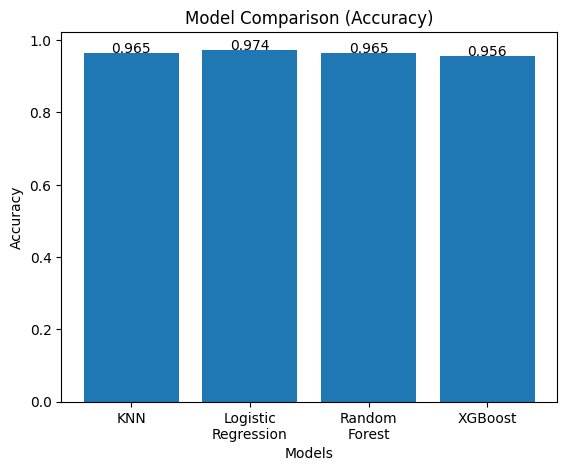

In [163]:
models = ['KNN', 'Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracies = [acc_knn, acc_lr, acc_rf, acc_xgb]

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Accuracy)")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.0005, f"{v:.3f}", ha='center')

plt.show()

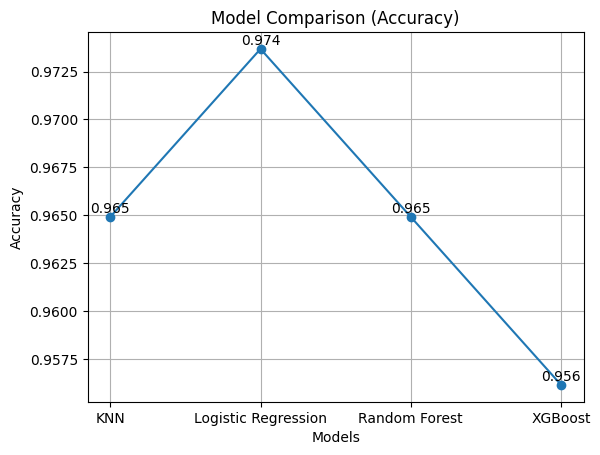

In [164]:

models = ['KNN', 'Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [acc_knn, acc_lr, acc_rf, acc_xgb]

plt.figure()

plt.plot(models, accuracies, marker='o', linestyle='-')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Accuracy)")


for i, v in enumerate(accuracies):
    plt.text(i, v + 0.0002, f"{v:.3f}", ha='center')

plt.grid()
plt.show()